# Deforestation_tracker_development

In [5]:

import ee
import geemap
import xarray as xr
import numpy as np
from datetime import datetime
import os

ee.Authenticate(auth_mode='localhost')
ee.Initialize(project='worldpeatland')

## Download S1 from GEE locally

In [9]:
"""
CLEAN S1 DOWNLOAD - PROPER GRID ALIGNMENT
==========================================
Downloads all 179 images in batches, all aligned to same grid
Handles 50MB limit, saves incrementally
"""

import ee
import geemap
import xarray as xr
import numpy as np
from datetime import datetime
import os

# ===================== SETUP =====================
bbox = [30.9260005950927983, 1.2490921020507799, 
        30.9897918701172017, 1.2923980951309200]
roi = ee.Geometry.Rectangle(bbox)

s1_collection = (ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(roi)
    .filterDate('2020-01-01', '2025-01-01')
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING'))
    .filter(ee.Filter.eq('relativeOrbitNumber_start', 123))
    .select(['VH'])
    .map(lambda img: img.clip(roi))
    .sort('system:time_start'))

n_total = s1_collection.size().getInfo()
print(f"Total images to download: {n_total}")

# Get all dates
dates_millis = s1_collection.aggregate_array('system:time_start').getInfo()
dates = [np.datetime64(datetime.fromtimestamp(d/1000)) for d in dates_millis]

print(f"Date range: {dates[0]} to {dates[-1]}")

# ===================== DEFINE REFERENCE GRID =====================
print("\nDefining reference grid from first image...")

img_list = s1_collection.toList(n_total)
first_img = ee.Image(img_list.get(0))
projection = first_img.select('VH').projection()

# Download first image to get dimensions
vh_first = geemap.ee_to_numpy(first_img.select('VH'), region=roi, scale=10)
if len(vh_first.shape) == 3:
    vh_first = vh_first[:, :, 0]

ny, nx = vh_first.shape

print(f"Reference grid: {ny} × {nx} pixels")
print(f"First image coverage: {np.sum(~np.isnan(vh_first) & (vh_first != 0)):,} pixels")

# ===================== DOWNLOAD IN BATCHES =====================
print(f"\nDownloading {n_total} images in batches of 10...")

output_dir = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries"
os.makedirs(output_dir, exist_ok=True)

batch_size = 10
n_batches = (n_total + batch_size - 1) // batch_size

all_data = []

for batch_idx in range(n_batches):
    start_idx = batch_idx * batch_size
    end_idx = min(start_idx + batch_size, n_total)
    
    print(f"\n[Batch {batch_idx+1}/{n_batches}] Images {start_idx+1}-{end_idx}...")
    
    # Initialize batch array
    batch_data = np.zeros((ny, nx, end_idx - start_idx))
    batch_dates = []
    
    # Download each image in this batch
    for i in range(start_idx, end_idx):
        local_idx = i - start_idx
        
        if (local_idx + 1) % 5 == 0 or local_idx == 0:
            print(f"  Downloading image {i+1}/{n_total}...")
        
        try:
            img = ee.Image(img_list.get(i))
            
            # CRITICAL: Reproject to reference grid
            img_reproj = img.select('VH').reproject(crs=projection, scale=10)
            
            # Download
            vh = geemap.ee_to_numpy(img_reproj, region=roi, scale=10)
            
            # Handle shape
            if len(vh.shape) == 3:
                vh = vh[:, :, 0]
            
            # Store
            if vh.shape == (ny, nx):
                batch_data[:, :, local_idx] = vh
                batch_dates.append(dates[i])
            else:
                print(f"    WARNING: Shape mismatch {vh.shape}, filling with NaN")
                batch_data[:, :, local_idx] = np.nan
                batch_dates.append(dates[i])
                
        except Exception as e:
            print(f"    ERROR downloading image {i+1}: {e}")
            batch_data[:, :, local_idx] = np.nan
            batch_dates.append(dates[i])
    
    # Check coverage
    valid_per_image = [np.sum(~np.isnan(batch_data[:,:,j]) & (batch_data[:,:,j] != 0)) 
                       for j in range(batch_data.shape[2])]
    avg_coverage = np.mean(valid_per_image) / (ny * nx) * 100
    print(f"  Batch average coverage: {avg_coverage:.1f}%")
    
    # Save batch
    batch_file = f"{output_dir}/s1_batch_{batch_idx:02d}.npz"
    np.savez_compressed(batch_file, 
                       data=batch_data, 
                       dates=np.array(batch_dates, dtype='datetime64[ns]'))
    print(f"  ✓ Saved to {batch_file}")
    
    all_data.append(batch_data)

# ===================== COMBINE ALL BATCHES =====================
print("\n" + "="*60)
print("COMBINING ALL BATCHES")
print("="*60)

vh_complete = np.concatenate(all_data, axis=2)

print(f"Complete dataset shape: {vh_complete.shape}")
print(f"Expected: ({ny}, {nx}, {n_total})")

# Calculate final coverage
valid_per_image = [np.sum(~np.isnan(vh_complete[:,:,i]) & (vh_complete[:,:,i] != 0)) 
                   for i in range(vh_complete.shape[2])]
avg_coverage = np.mean(valid_per_image) / (ny * nx) * 100
min_coverage = min(valid_per_image) / (ny * nx) * 100
max_coverage = max(valid_per_image) / (ny * nx) * 100

print(f"\nFinal coverage statistics:")
print(f"  Average: {avg_coverage:.1f}%")
print(f"  Min: {min_coverage:.1f}%")
print(f"  Max: {max_coverage:.1f}%")

# ===================== SAVE AS NETCDF =====================
print("\nSaving as NetCDF...")

lons = np.linspace(bbox[0], bbox[2], nx)
lats = np.linspace(bbox[3], bbox[1], ny)

ds = xr.Dataset(
    data_vars={'VH': (['y', 'x', 'time'], vh_complete)},
    coords={'x': lons, 'y': lats, 'time': dates},
    attrs={
        'description': 'S1 VH time series - properly aligned grid',
        'method': 'Individual downloads reprojected to common reference grid',
        'scale': 10,
        'reference_projection': str(projection.getInfo()),
    }
)

output_file = f"{output_dir}/s1_aligned.nc"
ds.to_netcdf(output_file, encoding={'VH': {'zlib': True, 'complevel': 5}})

print(f"✓ Saved to {output_file}")

# ===================== SUMMARY =====================
print("\n" + "="*60)
print("DOWNLOAD COMPLETE!")
print("="*60)
print(f"Total images: {n_total}")
print(f"Grid size: {ny} × {nx} pixels")
print(f"Average coverage: {avg_coverage:.1f}%")
print(f"File: {output_file}")
print()

if avg_coverage > 90:
    print("✅ EXCELLENT! Coverage >90% - data is dense and aligned!")
elif avg_coverage > 50:
    print("✅ GOOD! Coverage >50% - workable for analysis")
else:
    print("⚠️  Coverage is low but each pixel has complete time series")

print("\nReady for filtering and analysis!")

Total images to download: 179
Date range: 2020-01-04T03:36:10.000000 to 2024-12-20T03:36:28.000000

Defining reference grid from first image...
Reference grid: 480 × 712 pixels
First image coverage: 341,420 pixels


[Batch 1/18] Images 1-10...
  Batch average coverage: 99.9%
  ✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_batch_00.npz

[Batch 2/18] Images 11-20...
  Batch average coverage: 99.9%
  ✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_batch_01.npz

[Batch 3/18] Images 21-30...
  Batch average coverage: 99.9%
  ✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_batch_02.npz

[Batch 4/18] Images 31-40...
  Batch average coverage: 99.9%
  ✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_batch_03.npz

[Batch 5/18] Images 41-50...
  Batch average coverage: 99.9%
  ✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_batch_04.npz

[Batch 6/18] Images 51-60...
  Batch ave

/tmp/ipykernel_352918/3390374131.py:154: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds = xr.Dataset(


✓ Saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc

DOWNLOAD COMPLETE!
Total images: 179
Grid size: 480 × 712 pixels
Average coverage: 99.9%
File: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc

✅ EXCELLENT! Coverage >90% - data is dense and aligned!

Ready for filtering and analysis!


Dataset loaded: (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000


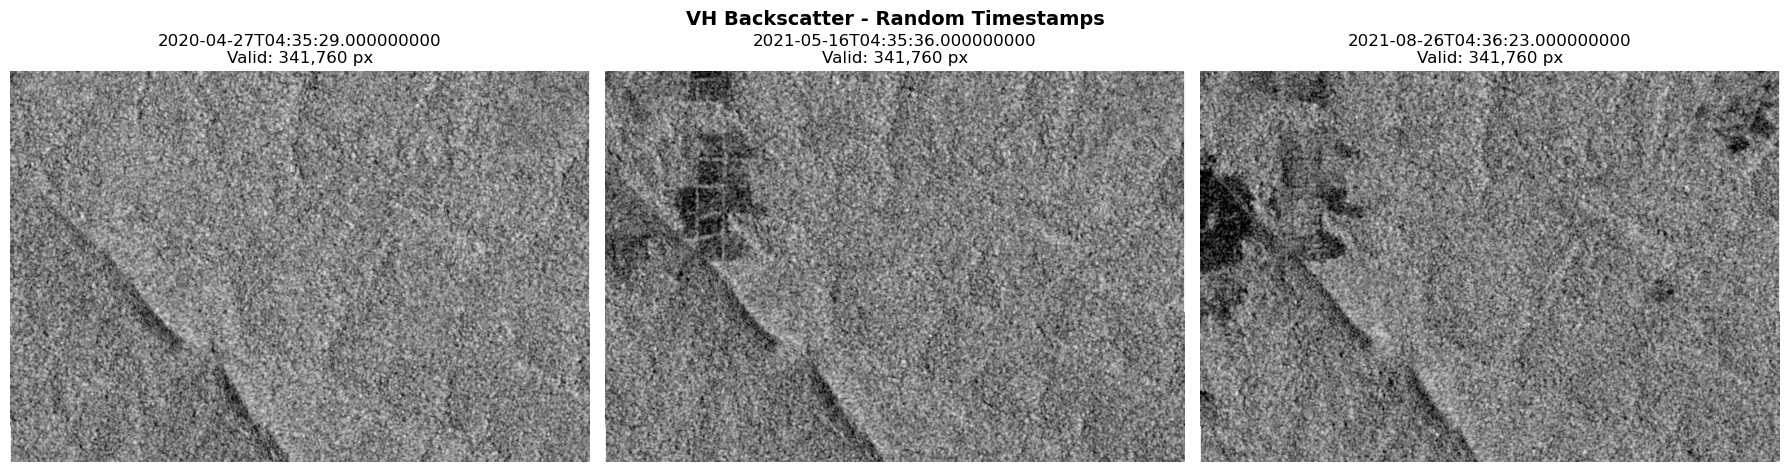


Coverage check:
  2020-04-27T04:35:29.000000000: 341,420 pixels (99.9%)
  2021-05-16T04:35:36.000000000: 341,420 pixels (99.9%)
  2021-08-26T04:36:23.000000000: 341,420 pixels (99.9%)


In [10]:
"""
VISUALIZE ALIGNED DATA
======================
"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the aligned data
file_path = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc"
ds = xr.open_dataset(file_path)

print(f"Dataset loaded: {ds.VH.shape}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

# Pick 3 random timestamps
np.random.seed(42)
random_indices = np.random.choice(len(ds.time), 3, replace=False)
random_indices = np.sort(random_indices)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, idx in enumerate(random_indices):
    vh = ds['VH'][:, :, idx].values
    
    axes[i].imshow(vh, cmap='gray', vmin=-25, vmax=-5)
    axes[i].set_title(f'{ds.time[idx].values}\nValid: {np.sum(~np.isnan(vh)):,} px', 
                     fontsize=12)
    axes[i].axis('off')

plt.suptitle('VH Backscatter - Random Timestamps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Stats
print("\nCoverage check:")
for idx in random_indices:
    vh = ds['VH'][:, :, idx].values
    valid = np.sum(~np.isnan(vh) & (vh != 0))
    print(f"  {ds.time[idx].values}: {valid:,} pixels ({valid/vh.size*100:.1f}%)")

## Workflow

In [ ]:
"""
COMPLETE LOCAL PROCESSING WORKFLOW
===================================
Apply forest mask, filters, and logistic fitting
"""

import xarray as xr
import numpy as np
import rasterio
from scipy.ndimage import uniform_filter
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ===================== LOAD DATA =====================
print("Loading complete time series...")
nc_complete = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc"
ds = xr.open_dataset(nc_complete)

print(f"Dataset: {ds.dims}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

vh_array = ds['VH'].values  # Shape: (y, x, time)
vv_array = ds['VV'].values

print(f"VH shape: {vh_array.shape}")

# ===================== LOAD AND APPLY FOREST MASK =====================
print("\nLoading forest mask...")
forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"

with rasterio.open(forest_mask_path) as src:
    forest_array = src.read(1)
    forest_transform = src.transform
    forest_crs = src.crs

print(f"Forest mask shape: {forest_array.shape}")
print(f"Forest pixels: {(forest_array == 1).sum():,}")

# Resample forest mask to match S1 grid
from scipy.ndimage import zoom

if forest_array.shape != vh_array.shape[:2]:
    print(f"Resampling forest mask from {forest_array.shape} to {vh_array.shape[:2]}...")
    zoom_factors = (vh_array.shape[0] / forest_array.shape[0], 
                    vh_array.shape[1] / forest_array.shape[1])
    forest_resampled = zoom(forest_array, zoom_factors, order=0)  # Nearest neighbor
else:
    forest_resampled = forest_array

print(f"Resampled forest mask: {forest_resampled.shape}")
print(f"Forest pixels in S1 grid: {(forest_resampled == 1).sum():,}")

# Apply mask to data (set non-forest to NaN)
vh_masked = vh_array.copy()
vh_masked[forest_resampled != 1, :] = np.nan

print(f"✓ Forest mask applied")



Loading complete time series...
Dataset: FrozenMappingWarningOnValuesAccess({'time': 175, 'y': 959, 'x': 1421})
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000
VH shape: (959, 1421, 175)

Loading forest mask...
Forest mask shape: (5284, 7508)
Forest pixels: 6,068,867
Resampling forest mask from (5284, 7508) to (959, 1421)...
Resampled forest mask: (959, 1421)
Forest pixels in S1 grid: 208,074
✓ Forest mask applied


In [11]:
"""
COMPLETE FILTERING PIPELINE - SIMPLE AND CLEAN
===============================================
1. Load S1 data
2. Apply Lee filter (7x7, radius 3.0)
3. Apply Quegan & Yu multitemporal (5 images)
4. Save filtered result
"""

import xarray as xr
import numpy as np
from scipy.ndimage import convolve

# ===================== 1. LOAD DATA =====================
print("=" * 60)
print("STEP 1: LOADING DATA")
print("=" * 60)

nc_complete = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_aligned.nc"
ds = xr.open_dataset(nc_complete)

vh_array = ds['VH'].values
print(f"Loaded: {vh_array.shape}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")
print(f"Valid pixels: {np.sum(~np.isnan(vh_array) & (vh_array != 0)):,}")

# ===================== 2. LEE FILTER (7x7) =====================
print("\n" + "=" * 60)
print("STEP 2: APPLYING LEE FILTER (7x7, radius 3.0)")
print("=" * 60)

def create_circular_kernel(radius=3.0):
    """Create circular kernel matching GEE focal_mean"""
    size = int(radius * 2 + 1)
    center = radius
    y, x = np.ogrid[-center:size-center, -center:size-center]
    mask = x**2 + y**2 <= radius**2
    return mask.astype(float)

def circular_mean(image, radius=3.0):
    """Calculate mean with circular kernel"""
    kernel = create_circular_kernel(radius)
    kernel = kernel / kernel.sum()
    return convolve(image, kernel, mode='reflect')

def lee_filter(data, radius=3.0):
    """
    Lee Filter (Lee, 1981)
    Reference: Lee, J.-S. (1981). Computer Graphics and Image Processing, 15, 380-389
    """
    cu_squared = 0.25  # For 4-look GRD
    filtered = np.zeros_like(data)
    
    for t in range(data.shape[2]):
        if t % 20 == 0:
            print(f"  Processing {t+1}/{data.shape[2]}...")
        
        img = data[:, :, t]
        
        # Local mean (circular window)
        mean = circular_mean(img, radius=radius)
        
        # Local variance: Var = E[X²] - E[X]²
        sqr_mean = circular_mean(img**2, radius=radius)
        variance = sqr_mean - mean**2
        variance = np.maximum(variance, 0)
        
        # Lee weight: W = (C_i² - C_u²) / C_i²
        ci_squared = variance / (mean**2 + 1e-10)
        w = np.clip((ci_squared - cu_squared) / (ci_squared + 1e-10), 0, 1)
        
        # Filtered output: I_filtered = μ + W × (I - μ)
        filtered[:, :, t] = mean + w * (img - mean)
    
    return filtered

vh_lee = lee_filter(vh_array, radius=3.0)
print("✓ Lee filter complete!")

# ===================== 3. QUEGAN & YU MULTITEMPORAL =====================
print("\n" + "=" * 60)
print("STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (5 images)")
print("=" * 60)

def quegan_yu_multitemporal(data, spatial_radius=3.0, temporal_window=5):
    """
    Quegan & Yu multitemporal filter
    For each time t: uses [t-2, t-1, t, t+1, t+2]
    Formula: Σ(I/μ) / Σ(1/μ)
    """
    ny, nx, nt = data.shape
    filtered = np.zeros_like(data)
    half_window = temporal_window // 2
    
    for t in range(nt):
        if t % 20 == 0:
            print(f"  Processing {t+1}/{nt}...")
        
        # Temporal window
        t_start = max(0, t - half_window)
        t_end = min(nt, t + half_window + 1)
        
        # Accumulators
        sum_norm = np.zeros((ny, nx))
        sum_inv = np.zeros((ny, nx))
        
        # Sum over temporal window
        for tt in range(t_start, t_end):
            img = data[:, :, tt]
            
            # Local spatial mean
            local_mean = circular_mean(img, radius=spatial_radius)
            
            # Normalize and accumulate
            sum_norm = np.nansum([sum_norm, img / (local_mean + 1e-10)], axis=0)
            sum_inv = np.nansum([sum_inv, 1.0 / (local_mean + 1e-10)], axis=0)
        
        # Final result: Σ(I/μ) / Σ(1/μ)
        filtered[:, :, t] = sum_norm / (sum_inv + 1e-10)
    
    return filtered

vh_filtered = quegan_yu_multitemporal(vh_lee, spatial_radius=3.0, temporal_window=5)
print("✓ Quegan & Yu filter complete!")

# ===================== 4. SAVE RESULT =====================
print("\n" + "=" * 60)
print("STEP 4: SAVING FILTERED DATA")
print("=" * 60)

# Create output dataset
ds_filtered = xr.Dataset(
    data_vars={
        'VH_filtered': (['y', 'x', 'time'], vh_filtered),
        'VH_lee': (['y', 'x', 'time'], vh_lee),
        'VH_raw': (['y', 'x', 'time'], vh_array),
    },
    coords={
        'x': ds.x,
        'y': ds.y,
        'time': ds.time,
    },
    attrs={
        'description': 'Filtered S1 time series',
        'filters': 'Lee (7x7, r=3.0) + Quegan & Yu multitemporal (5 images)',
        'lee_reference': 'Lee, J.-S. (1981). Computer Graphics and Image Processing, 15, 380-389',
        'temporal_window': 5,
        'spatial_radius': 3.0,
    }
)

output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"

encoding = {
    'VH_filtered': {'zlib': True, 'complevel': 5},
    'VH_lee': {'zlib': True, 'complevel': 5},
    'VH_raw': {'zlib': True, 'complevel': 5},
}

ds_filtered.to_netcdf(output_file, encoding=encoding)

print(f"✓ Saved to: {output_file}")

# ===================== SUMMARY =====================
print("\n" + "=" * 60)
print("FILTERING COMPLETE!")
print("=" * 60)
print("Applied filters:")
print("  1. Lee filter (Lee, 1981)")
print("     - Circular window: radius 3.0 (7×7)")
print("     - Reduces speckle noise")
print()
print("  2. Quegan & Yu multitemporal filter")
print("     - Temporal window: 5 images (t-2, t-1, t, t+1, t+2)")
print("     - Spatial window: 7×7 (radius 3.0)")
print("     - Reduces temporal noise")
print()
print(f"Output saved to: {output_file}")
print("\nReady for deforestation analysis!")

STEP 1: LOADING DATA
Loaded: (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000
Valid pixels: 61,114,180

STEP 2: APPLYING LEE FILTER (7x7, radius 3.0)
  Processing 1/179...
  Processing 21/179...
  Processing 41/179...
  Processing 61/179...
  Processing 81/179...
  Processing 101/179...
  Processing 121/179...
  Processing 141/179...
  Processing 161/179...
✓ Lee filter complete!

STEP 3: APPLYING QUEGAN & YU MULTITEMPORAL FILTER (5 images)
  Processing 1/179...
  Processing 21/179...
  Processing 41/179...
  Processing 61/179...
  Processing 81/179...
  Processing 101/179...
  Processing 121/179...
  Processing 141/179...
  Processing 161/179...
✓ Quegan & Yu filter complete!

STEP 4: SAVING FILTERED DATA
✓ Saved to: /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc

FILTERING COMPLETE!
Applied filters:
  1. Lee filter (Lee, 1981)
     - Circular window: radius 3.0 (7×7)
     - Reduces speckle noise

  2. Quegan & Yu mul

Loading filtered data...
Timestamp: 2021-11-18T03:36:24.000000000


/tmp/ipykernel_368582/290670176.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


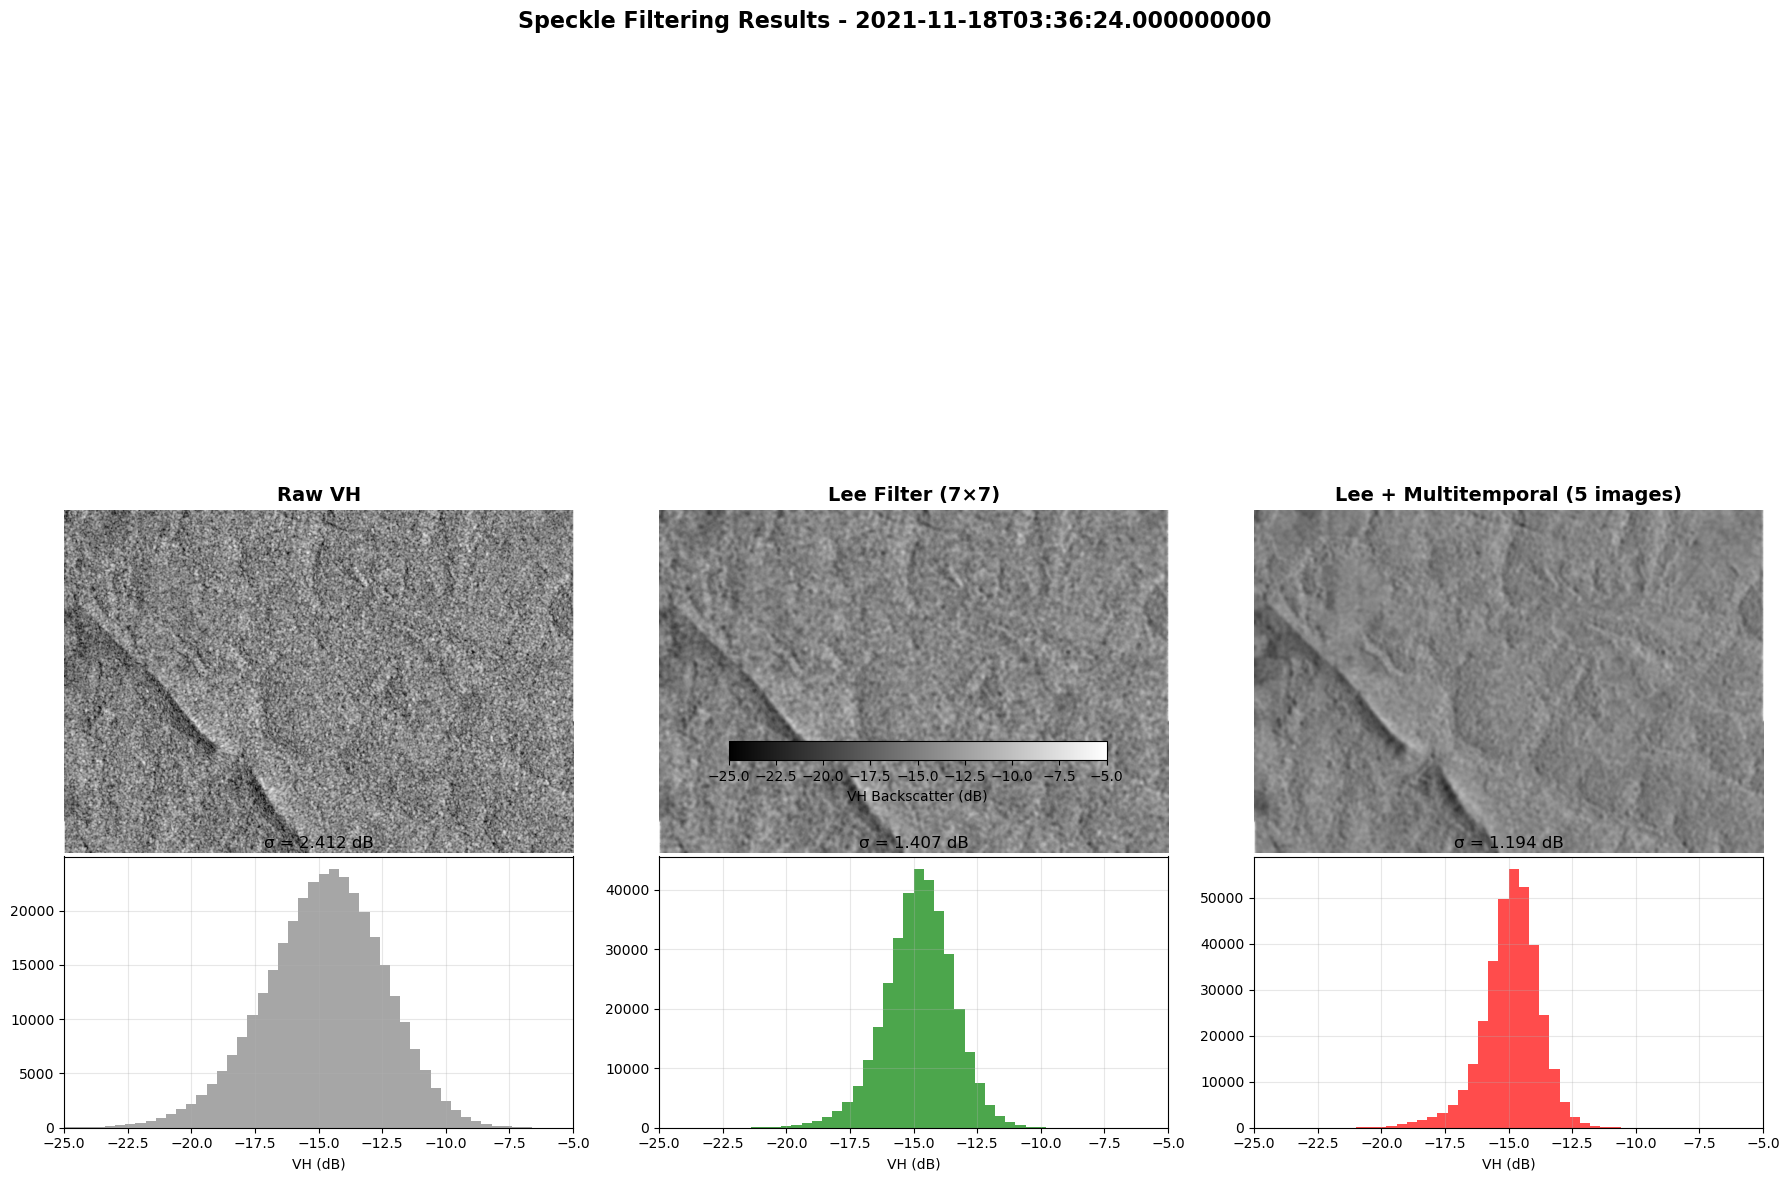


📊 SPECKLE REDUCTION (lower σ = better)
  Raw:            σ = 2.412 dB
  Lee Filter:     σ = 1.407 dB  (41.6% reduction)
  Multitemporal:  σ = 1.194 dB  (50.5% reduction)

✓ Filters successfully reduced speckle noise!


In [1]:
"""
VISUALIZE FILTERING RESULTS - SIMPLIFIED
=========================================
No gap filling needed with dense data!
"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===================== LOAD FILTERED DATA =====================
print("Loading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
ds = xr.open_dataset(filtered_file)

# Pick a middle timestamp
t = 87  # Mid 2021

vh_raw = ds['VH_raw'][:, :, t].values
vh_lee = ds['VH_lee'][:, :, t].values
vh_filtered = ds['VH_filtered'][:, :, t].values

print(f"Timestamp: {ds.time[t].values}")

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 3, figsize=(18, 12), 
                         gridspec_kw={'height_ratios': [3, 1]})

vmin, vmax = -25, -5

# Top row: Images
axes[0, 0].imshow(vh_raw, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 0].set_title('Raw VH', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(vh_lee, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 1].set_title('Lee Filter (7×7)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(vh_filtered, cmap='gray', vmin=vmin, vmax=vmax)
axes[0, 2].set_title('Lee + Multitemporal (5 images)', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# Bottom row: Histograms
axes[1, 0].hist(vh_raw.flatten(), bins=50, color='gray', alpha=0.7, range=(vmin, vmax))
axes[1, 0].set_xlabel('VH (dB)')
axes[1, 0].set_xlim(vmin, vmax)
axes[1, 0].set_title(f'σ = {np.nanstd(vh_raw):.3f} dB', fontsize=12)
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(vh_lee.flatten(), bins=50, color='green', alpha=0.7, range=(vmin, vmax))
axes[1, 1].set_xlabel('VH (dB)')
axes[1, 1].set_xlim(vmin, vmax)
axes[1, 1].set_title(f'σ = {np.nanstd(vh_lee):.3f} dB', fontsize=12)
axes[1, 1].grid(alpha=0.3)

axes[1, 2].hist(vh_filtered.flatten(), bins=50, color='red', alpha=0.7, range=(vmin, vmax))
axes[1, 2].set_xlabel('VH (dB)')
axes[1, 2].set_xlim(vmin, vmax)
axes[1, 2].set_title(f'σ = {np.nanstd(vh_filtered):.3f} dB', fontsize=12)
axes[1, 2].grid(alpha=0.3)

# Add colorbar
fig.colorbar(axes[0, 2].images[0], ax=axes[0, :], orientation='horizontal', 
             label='VH Backscatter (dB)', pad=0.02, fraction=0.03)

plt.suptitle(f'Speckle Filtering Results - {ds.time[t].values}', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("📊 SPECKLE REDUCTION (lower σ = better)")
print("="*60)

raw_std = np.nanstd(vh_raw)
lee_std = np.nanstd(vh_lee)
filt_std = np.nanstd(vh_filtered)

print(f"  Raw:            σ = {raw_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_std:.3f} dB  ({(1-lee_std/raw_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_std:.3f} dB  ({(1-filt_std/raw_std)*100:.1f}% reduction)")
print("\n✓ Filters successfully reduced speckle noise!")

Loading filtered data...
Timestamp: 2021-11-18T03:36:24.000000000
Zoom region: (100, 100)


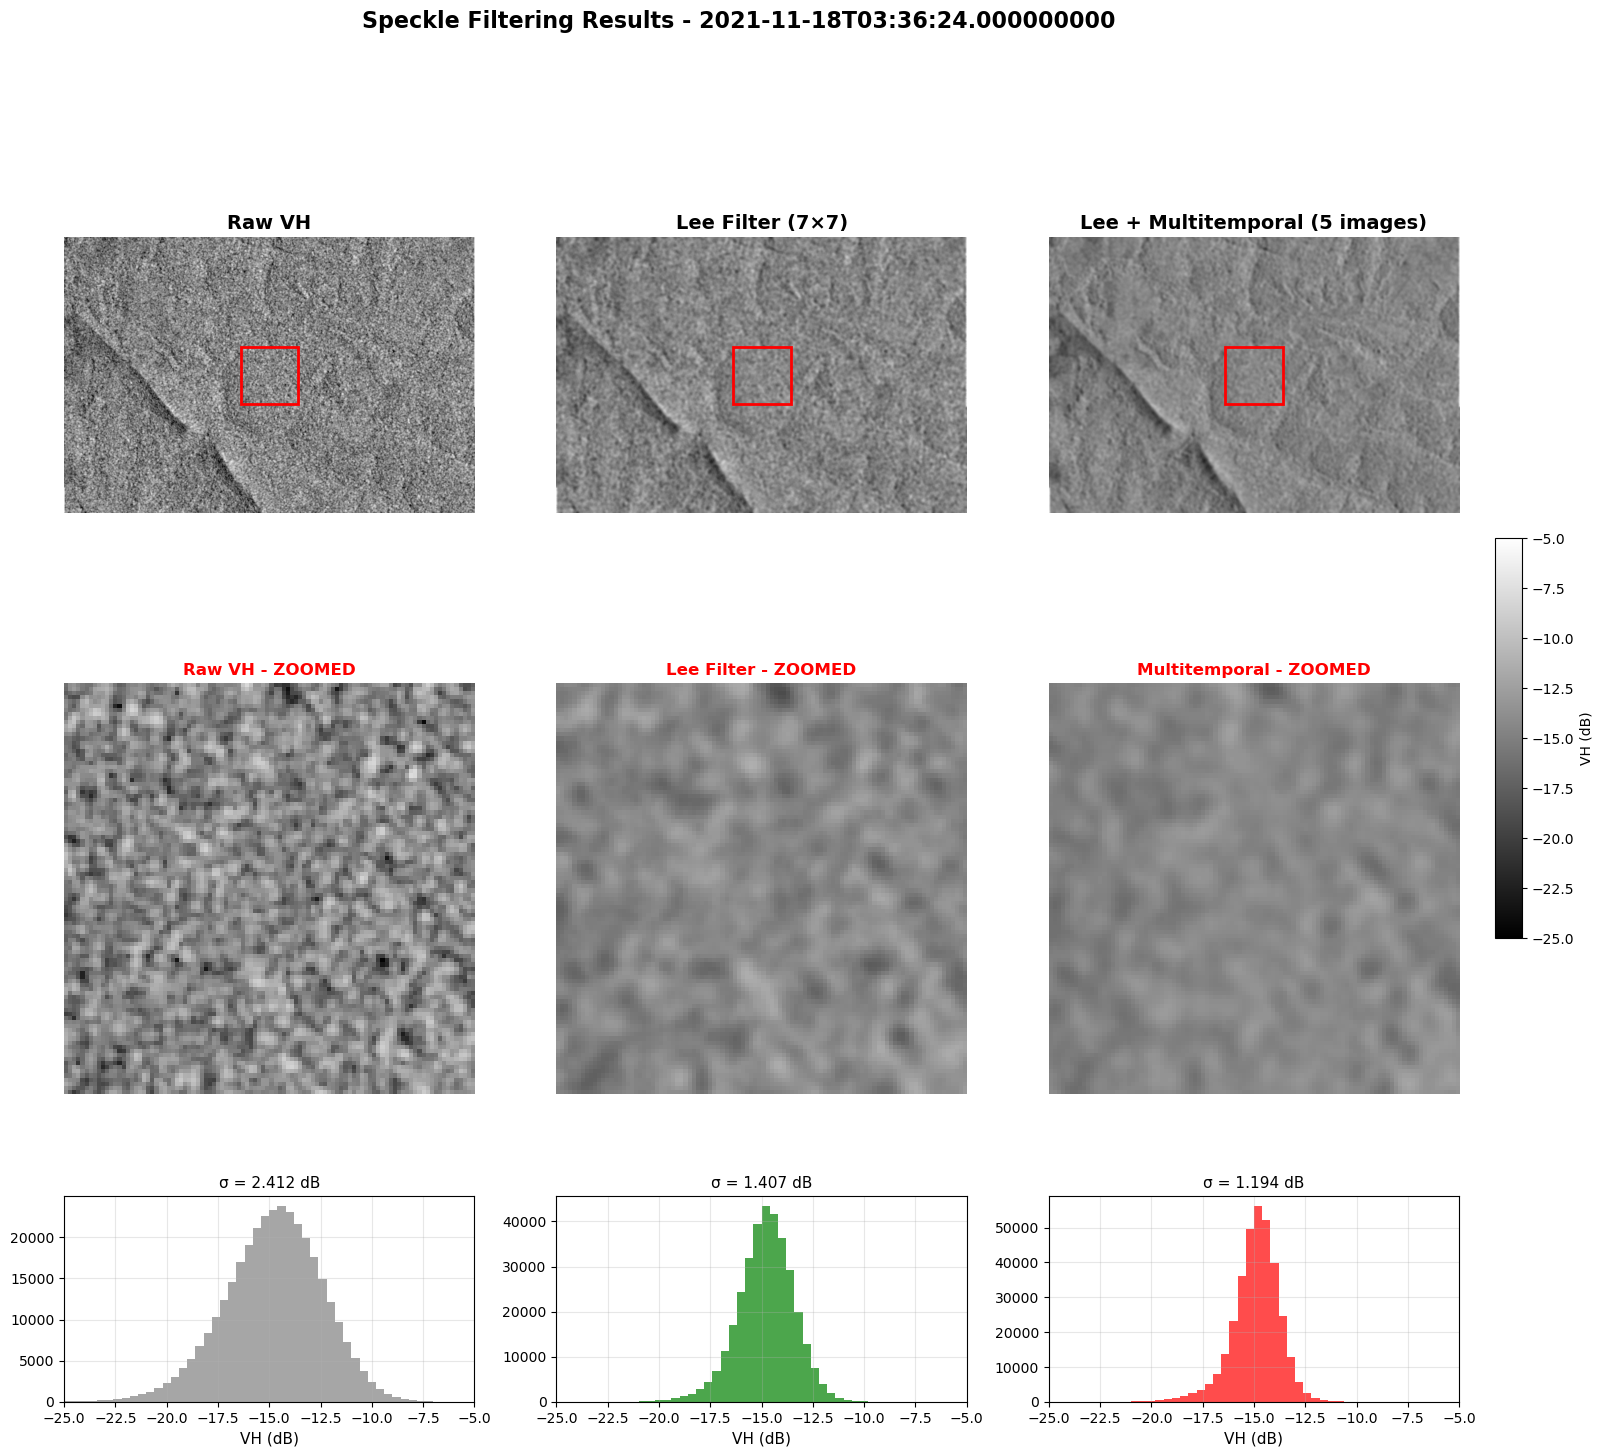


📊 SPECKLE REDUCTION (lower σ = better)
Full image:
  Raw:            σ = 2.412 dB
  Lee Filter:     σ = 1.407 dB  (41.6% reduction)
  Multitemporal:  σ = 1.194 dB  (50.5% reduction)

Zoomed region:
  Raw:            σ = 2.179 dB
  Lee Filter:     σ = 1.029 dB  (52.8% reduction)
  Multitemporal:  σ = 0.734 dB  (66.3% reduction)

✓ Filters successfully reduced speckle noise!


In [2]:
"""
VISUALIZE FILTERING RESULTS - WITH ZOOM
========================================
"""

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ===================== LOAD FILTERED DATA =====================
print("Loading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
ds = xr.open_dataset(filtered_file)

# Pick a middle timestamp
t = 87  # Mid 2021

vh_raw = ds['VH_raw'][:, :, t].values
vh_lee = ds['VH_lee'][:, :, t].values
vh_filtered = ds['VH_filtered'][:, :, t].values

print(f"Timestamp: {ds.time[t].values}")

# ===================== EXTRACT ZOOM REGION =====================
# Extract 100x100 region from center
ny, nx = vh_raw.shape
center_y, center_x = ny // 2, nx // 2
size = 50

y_start = center_y - size
y_end = center_y + size
x_start = center_x - size
x_end = center_x + size

vh_raw_zoom = vh_raw[y_start:y_end, x_start:x_end]
vh_lee_zoom = vh_lee[y_start:y_end, x_start:x_end]
vh_filtered_zoom = vh_filtered[y_start:y_end, x_start:x_end]

print(f"Zoom region: {vh_raw_zoom.shape}")

# ===================== PLOT =====================
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 3, height_ratios=[2, 2, 1], hspace=0.3, wspace=0.2)

vmin, vmax = -25, -5

# Row 1: Full images
ax00 = fig.add_subplot(gs[0, 0])
ax00.imshow(vh_raw, cmap='gray', vmin=vmin, vmax=vmax)
ax00.set_title('Raw VH', fontsize=14, fontweight='bold')
ax00.axis('off')
# Mark zoom region
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax00.add_patch(rect)

ax01 = fig.add_subplot(gs[0, 1])
ax01.imshow(vh_lee, cmap='gray', vmin=vmin, vmax=vmax)
ax01.set_title('Lee Filter (7×7)', fontsize=14, fontweight='bold')
ax01.axis('off')
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax01.add_patch(rect)

ax02 = fig.add_subplot(gs[0, 2])
ax02.imshow(vh_filtered, cmap='gray', vmin=vmin, vmax=vmax)
ax02.set_title('Lee + Multitemporal (5 images)', fontsize=14, fontweight='bold')
ax02.axis('off')
rect = plt.Rectangle((x_start, y_start), 2*size, 2*size, 
                     fill=False, color='red', linewidth=2)
ax02.add_patch(rect)

# Row 2: Zoomed images
ax10 = fig.add_subplot(gs[1, 0])
ax10.imshow(vh_raw_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax10.set_title('Raw VH - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax10.axis('off')

ax11 = fig.add_subplot(gs[1, 1])
ax11.imshow(vh_lee_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax11.set_title('Lee Filter - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax11.axis('off')

ax12 = fig.add_subplot(gs[1, 2])
im = ax12.imshow(vh_filtered_zoom, cmap='gray', vmin=vmin, vmax=vmax)
ax12.set_title('Multitemporal - ZOOMED', fontsize=12, fontweight='bold', color='red')
ax12.axis('off')

# Add colorbar for zoomed images
cbar_ax = fig.add_axes([0.92, 0.40, 0.015, 0.25])
fig.colorbar(im, cax=cbar_ax, label='VH (dB)')

# Row 3: Histograms
ax20 = fig.add_subplot(gs[2, 0])
ax20.hist(vh_raw.flatten(), bins=50, color='gray', alpha=0.7, range=(vmin, vmax))
ax20.set_xlabel('VH (dB)', fontsize=11)
ax20.set_xlim(vmin, vmax)
ax20.set_title(f'σ = {np.nanstd(vh_raw):.3f} dB', fontsize=11)
ax20.grid(alpha=0.3)

ax21 = fig.add_subplot(gs[2, 1])
ax21.hist(vh_lee.flatten(), bins=50, color='green', alpha=0.7, range=(vmin, vmax))
ax21.set_xlabel('VH (dB)', fontsize=11)
ax21.set_xlim(vmin, vmax)
ax21.set_title(f'σ = {np.nanstd(vh_lee):.3f} dB', fontsize=11)
ax21.grid(alpha=0.3)

ax22 = fig.add_subplot(gs[2, 2])
ax22.hist(vh_filtered.flatten(), bins=50, color='red', alpha=0.7, range=(vmin, vmax))
ax22.set_xlabel('VH (dB)', fontsize=11)
ax22.set_xlim(vmin, vmax)
ax22.set_title(f'σ = {np.nanstd(vh_filtered):.3f} dB', fontsize=11)
ax22.grid(alpha=0.3)

plt.suptitle(f'Speckle Filtering Results - {ds.time[t].values}', 
             fontsize=16, fontweight='bold', y=0.98)

plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("📊 SPECKLE REDUCTION (lower σ = better)")
print("="*60)

raw_std = np.nanstd(vh_raw)
lee_std = np.nanstd(vh_lee)
filt_std = np.nanstd(vh_filtered)

print(f"Full image:")
print(f"  Raw:            σ = {raw_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_std:.3f} dB  ({(1-lee_std/raw_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_std:.3f} dB  ({(1-filt_std/raw_std)*100:.1f}% reduction)")

raw_zoom_std = np.nanstd(vh_raw_zoom)
lee_zoom_std = np.nanstd(vh_lee_zoom)
filt_zoom_std = np.nanstd(vh_filtered_zoom)

print(f"\nZoomed region:")
print(f"  Raw:            σ = {raw_zoom_std:.3f} dB")
print(f"  Lee Filter:     σ = {lee_zoom_std:.3f} dB  ({(1-lee_zoom_std/raw_zoom_std)*100:.1f}% reduction)")
print(f"  Multitemporal:  σ = {filt_zoom_std:.3f} dB  ({(1-filt_zoom_std/raw_zoom_std)*100:.1f}% reduction)")

print("\n✓ Filters successfully reduced speckle noise!")

## Temporal Variability

In [ ]:
"""
CALCULATE TEMPORAL VARIABILITY - LOCAL VERSION
===============================================
Adapted from GEE approach, runs on local aligned data
"""

import xarray as xr
import numpy as np
import rasterio
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

# ===================== LOAD FILTERED DATA =====================
print("="*60)
print("STEP 1: LOADING DATA")
print("="*60)

filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
ds = xr.open_dataset(filtered_file)

# Use multitemporal filtered data
vh_data = ds['VH_filtered'].values
print(f"Loaded: {vh_data.shape}")
print(f"Date range: {ds.time[0].values} to {ds.time[-1].values}")

# ===================== LOAD FOREST MASK =====================
print("\nLoading forest mask...")
forest_mask_path = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020.tif"

with rasterio.open(forest_mask_path) as src:
    forest_array = src.read(1)
    forest_crs = src.crs

print(f"Forest mask: {forest_array.shape}")

# # Resample to match S1 grid    <-- reprojec tand clip here!
# if forest_array.shape != vh_data.shape[:2]:
#     zoom_factors = (vh_data.shape[0] / forest_array.shape[0], 
#                     vh_data.shape[1] / forest_array.shape[1])
#     forest_mask = zoom(forest_array, zoom_factors, order=0)
# else:
#     forest_mask = forest_array

# forest_mask = (forest_mask > 0).astype(bool)
# print(f"Resampled forest mask: {forest_mask.shape}")
# print(f"Forest pixels: {forest_mask.sum():,}")

# ===================== CALCULATE TEMPORAL STATISTICS =====================
print("\n" + "="*60)
print("STEP 2: TEMPORAL VARIABILITY")
print("="*60)

print("\nCalculating temporal statistics...")

# Standard deviation over time
std_dev = np.nanstd(vh_data, axis=2)

# Percentiles
p05 = np.nanpercentile(vh_data, 5, axis=2)
p95 = np.nanpercentile(vh_data, 95, axis=2)

print("✓ Statistics calculated")

# ===================== THRESHOLD SELECTION =====================
# Choose your method
USE_FIXED_SIGMA = True  # Set to True for manual, False for percentile

if USE_FIXED_SIGMA:
    # Manual sigma threshold (dB)
    tv_threshold = 0.3  # Adjust this value!
    print(f"\n✓ Using FIXED sigma threshold: {tv_threshold:.3f} dB")
    
else:
    # Automatic percentile threshold
    TV_PERCENTILE = 85
    # Calculate percentile only within forest mask
    forest_std = std_dev[forest_mask]
    tv_threshold = np.nanpercentile(forest_std, TV_PERCENTILE)
    print(f"\n✓ Using PERCENTILE threshold (p{TV_PERCENTILE}): {tv_threshold:.3f} dB")

# ===================== FIND CANDIDATE PIXELS =====================
print("\nFinding candidate pixels...")

# Create candidate mask (high variability + forest)
candidate_mask = (std_dev >= tv_threshold) & forest_mask

n_candidates = candidate_mask.sum()
n_forest = forest_mask.sum()
candidate_percent = (n_candidates / n_forest * 100) if n_forest > 0 else 0

print(f"Candidate pixels: {n_candidates:,} ({candidate_percent:.1f}% of forest)")



STEP 1: LOADING DATA
Loaded: (480, 712, 179)
Date range: 2020-01-04T03:36:10.000000000 to 2024-12-20T03:36:28.000000000

Loading forest mask...
Forest mask: (5284, 7508)
Resampled forest mask: (480, 712)
Forest pixels: 52,041

STEP 2: TEMPORAL VARIABILITY

Calculating temporal statistics...
✓ Statistics calculated

✓ Using FIXED sigma threshold: 0.300 dB

Finding candidate pixels...
Candidate pixels: 52,035 (100.0% of forest)



Visualizing results...


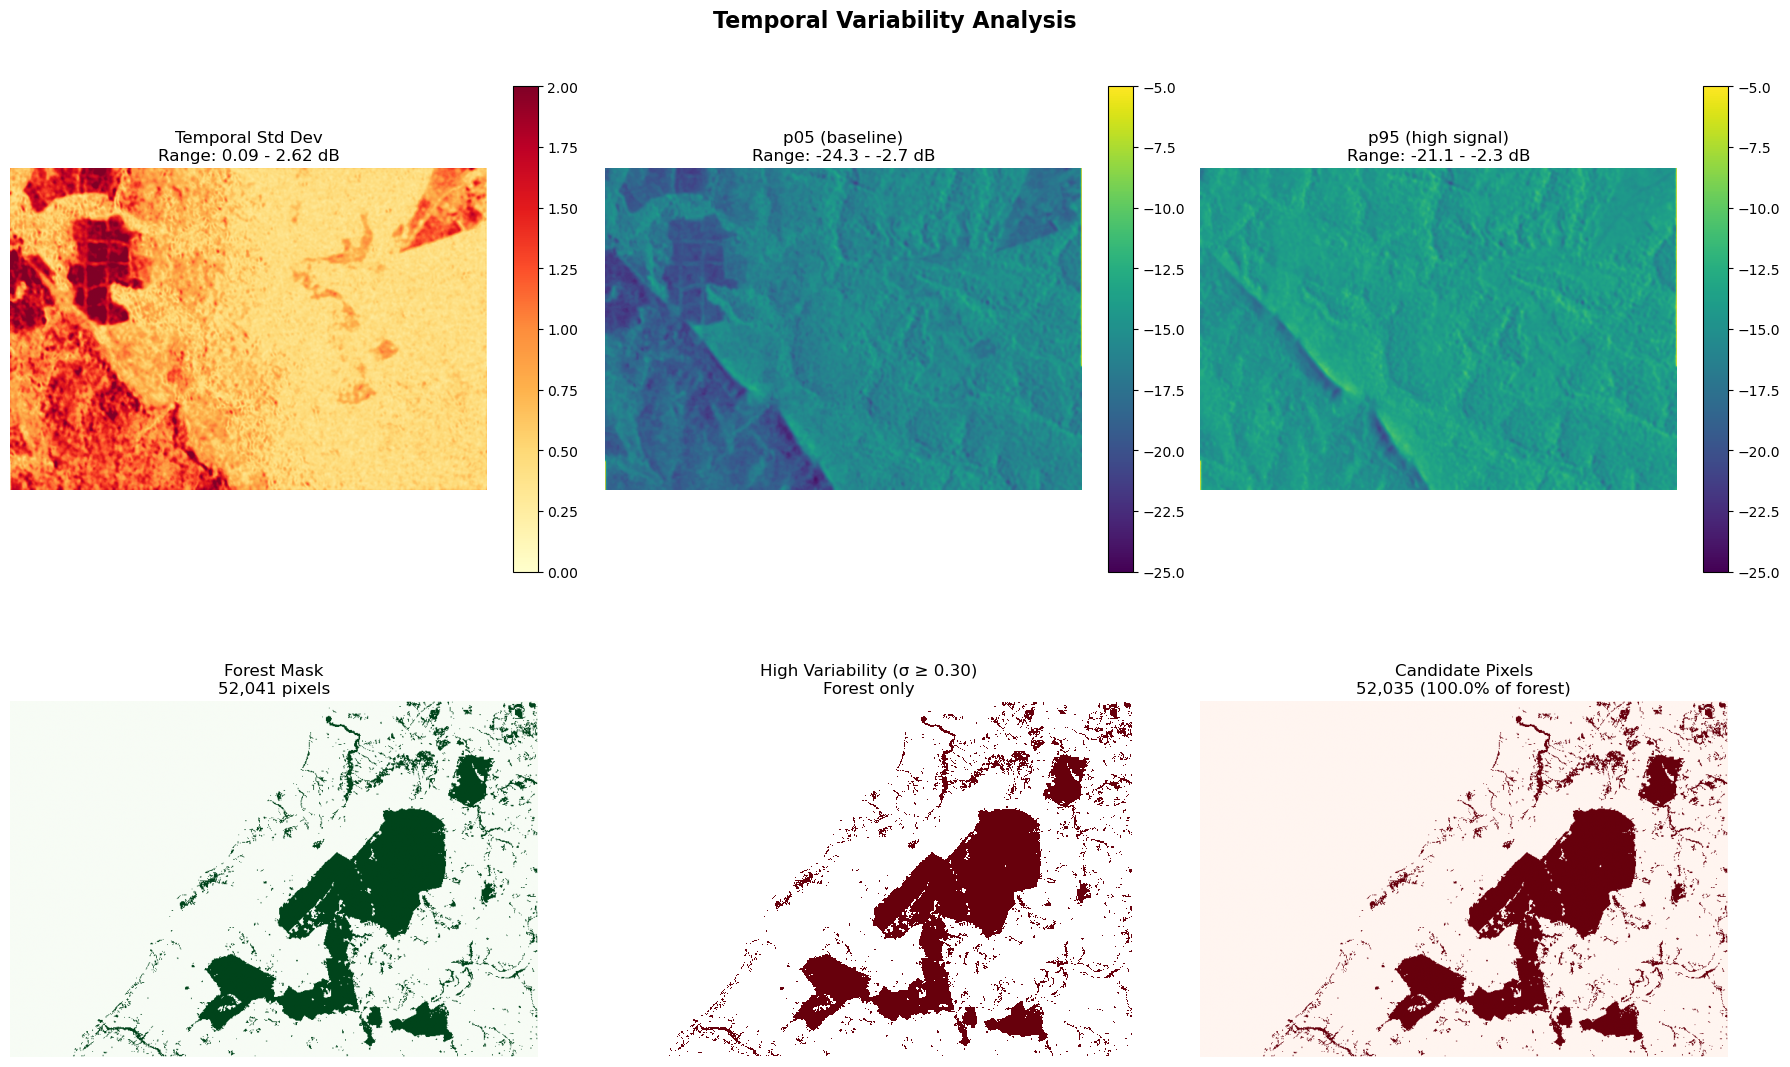


SUMMARY STATISTICS

Standard Deviation (all pixels):
  Min:  0.093 dB
  Mean: 0.775 dB
  Max:  2.620 dB

Standard Deviation (forest only):
  Min:  0.276 dB
  Mean: 0.567 dB
  Max:  2.461 dB

Threshold: 0.300 dB
Candidates: 52,035 pixels (100.0% of forest)

✓ Ready for deforestation detection!

✓ Results saved to /home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability.pkl


In [6]:
# ===================== VISUALIZE =====================
print("\nVisualizing results...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1
# Standard deviation
im1 = axes[0, 0].imshow(std_dev, cmap='YlOrRd', vmin=0, vmax=2)
axes[0, 0].set_title(f'Temporal Std Dev\nRange: {np.nanmin(std_dev):.2f} - {np.nanmax(std_dev):.2f} dB')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# p05
im2 = axes[0, 1].imshow(p05, cmap='viridis', vmin=-25, vmax=-5)
axes[0, 1].set_title(f'p05 (baseline)\nRange: {np.nanmin(p05):.1f} - {np.nanmax(p05):.1f} dB')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046)

# p95
im3 = axes[0, 2].imshow(p95, cmap='viridis', vmin=-25, vmax=-5)
axes[0, 2].set_title(f'p95 (high signal)\nRange: {np.nanmin(p95):.1f} - {np.nanmax(p95):.1f} dB')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# Row 2
# Forest mask
axes[1, 0].imshow(forest_mask, cmap='Greens')
axes[1, 0].set_title(f'Forest Mask\n{n_forest:,} pixels')
axes[1, 0].axis('off')

# High variability (within forest)
high_var_masked = np.ma.masked_where(~forest_mask, std_dev >= tv_threshold)
axes[1, 1].imshow(high_var_masked, cmap='Reds', interpolation='none')
axes[1, 1].set_title(f'High Variability (σ ≥ {tv_threshold:.2f})\nForest only')
axes[1, 1].axis('off')

# Candidate pixels
axes[1, 2].imshow(candidate_mask, cmap='Reds')
axes[1, 2].set_title(f'Candidate Pixels\n{n_candidates:,} ({candidate_percent:.1f}% of forest)')
axes[1, 2].axis('off')

plt.suptitle('Temporal Variability Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

# Overall
print(f"\nStandard Deviation (all pixels):")
print(f"  Min:  {np.nanmin(std_dev):.3f} dB")
print(f"  Mean: {np.nanmean(std_dev):.3f} dB")
print(f"  Max:  {np.nanmax(std_dev):.3f} dB")

# Forest only
forest_std = std_dev[forest_mask]
print(f"\nStandard Deviation (forest only):")
print(f"  Min:  {np.nanmin(forest_std):.3f} dB")
print(f"  Mean: {np.nanmean(forest_std):.3f} dB")
print(f"  Max:  {np.nanmax(forest_std):.3f} dB")

print(f"\nThreshold: {tv_threshold:.3f} dB")
print(f"Candidates: {n_candidates:,} pixels ({candidate_percent:.1f}% of forest)")

print("\n✓ Ready for deforestation detection!")

# ===================== SAVE RESULTS =====================
# Optional: save for next step
results = {
    'std_dev': std_dev,
    'p05': p05,
    'p95': p95,
    'candidate_mask': candidate_mask,
    'forest_mask': forest_mask,
    'tv_threshold': tv_threshold
}

import pickle
output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability.pkl"
with open(output_file, 'wb') as f:
    pickle.dump(results, f)
print(f"\n✓ Results saved to {output_file}")

## Logistic Fitting

In [8]:
"""
LOGISTIC FITTING - LOCAL VERSION
=================================
Fits logistic curves to detect deforestation timing
"""

import numpy as np
import pickle
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import xarray as xr

# ===================== LOAD DATA =====================
print("="*60)
print("STEP 3: LOGISTIC FITTING")
print("="*60)

# Load filtered data
print("\nLoading filtered data...")
filtered_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/s1_filtered.nc"
ds = xr.open_dataset(filtered_file)
vh_data = ds['VH_filtered'].values

# Load temporal variability results
print("Loading temporal variability results...")
with open("/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/temporal_variability.pkl", 'rb') as f:
    tv_results = pickle.load(f)

std_dev = tv_results['std_dev']
p05 = tv_results['p05']
p95 = tv_results['p95']
candidate_mask = tv_results['candidate_mask']
forest_mask = tv_results['forest_mask']

print(f"Time series length: {vh_data.shape[2]} images")
print(f"Candidates: {candidate_mask.sum():,} pixels")

# ===================== CALCULATE PARAMETERS =====================
print("\nCalculating parameters...")

amp = p95 - p05
flattening = amp / np.abs(p95)

print(f"Amplitude range: {np.nanmin(amp):.2f} to {np.nanmax(amp):.2f} dB")
print(f"Flattening range: {np.nanmin(flattening):.3f} to {np.nanmax(flattening):.3f}")

# ===================== FIT LOGISTIC CURVES =====================
print("\nFitting logistic curves...")

# Parameters
A_STEEPNESS = -2.0
N_WINDOW = 5
M = vh_data.shape[2]

# Valid t0 range
idx_min = N_WINDOW
idx_max = M - N_WINDOW - 1
t0_candidates = np.arange(idx_min, idx_max + 1)

print(f"Testing {len(t0_candidates)} inflection points per pixel...")
print(f"Steepness: {A_STEEPNESS}, Window: ±{N_WINDOW}")

def fit_logistic_pixel(time_series, lower, amp, a_steepness, n_window, t0_candidates):
    """
    Fit logistic curve to single pixel time series
    Returns best t0 and minimum SSE
    """
    M = len(time_series)
    obs_idx = np.arange(M)
    
    best_sse = np.inf
    best_t0 = None
    
    for t0 in t0_candidates:
        # Logistic function: k / (1 + e^(-a(t-t0))) + lower
        exponent = -a_steepness * (obs_idx - t0)
        y_pred = amp / (1 + np.exp(exponent)) + lower
        
        # Calculate residuals within window
        in_window = (obs_idx >= t0 - n_window) & (obs_idx <= t0 + n_window)
        residuals = time_series[in_window] - y_pred[in_window]
        
        # SSE (only on valid data)
        valid = ~np.isnan(residuals)
        if valid.sum() > 0:
            sse = np.sum(residuals[valid]**2)
            
            if sse < best_sse:
                best_sse = sse
                best_t0 = t0
    
    return best_t0, best_sse

# Initialize output arrays
best_t0_map = np.full(vh_data.shape[:2], np.nan)
best_sse_map = np.full(vh_data.shape[:2], np.nan)

# Get candidate pixel locations
candidate_rows, candidate_cols = np.where(candidate_mask)
n_candidates = len(candidate_rows)

print(f"\nProcessing {n_candidates:,} candidate pixels...")

# Process each candidate pixel
for idx, (i, j) in enumerate(zip(candidate_rows, candidate_cols)):
    if idx % 1000 == 0:
        print(f"  {idx:,}/{n_candidates:,} ({idx/n_candidates*100:.1f}%)...")
    
    # Get time series
    ts = vh_data[i, j, :]
    
    # Skip if too many NaN values
    if np.sum(~np.isnan(ts)) < M * 0.5:
        continue
    
    # Fit logistic
    t0, sse = fit_logistic_pixel(
        ts, 
        lower=p05[i, j], 
        amp=amp[i, j],
        a_steepness=A_STEEPNESS,
        n_window=N_WINDOW,
        t0_candidates=t0_candidates
    )
    
    best_t0_map[i, j] = t0
    best_sse_map[i, j] = sse

print(f"✓ Fitting complete!")
print(f"  Valid fits: {np.sum(~np.isnan(best_t0_map)):,}")

# ===================== CONVERT TO DATES (SIMPLER VERSION) =====================
print("\nConverting indices to dates...")

import pandas as pd

# Get time array
time_array = ds.time.values

# Average interval
time_diffs = np.diff(time_array.astype('datetime64[D]').astype(int))
avg_interval_days = np.median(time_diffs)
print(f"Average interval: {avg_interval_days:.1f} days")

# Convert t0 to dates
defor_dates = np.full(vh_data.shape[:2], np.datetime64('NaT'), dtype='datetime64[ns]')
defor_years = np.full(vh_data.shape[:2], np.nan)

valid_t0 = ~np.isnan(best_t0_map)
for i, j in zip(*np.where(valid_t0)):
    t0_idx = int(best_t0_map[i, j])
    
    # Get date
    defor_dates[i, j] = time_array[t0_idx]
    
    # Convert to decimal year using pandas
    ts = pd.Timestamp(time_array[t0_idx])
    day_of_year = ts.dayofyear
    days_in_year = 366 if ts.is_leap_year else 365
    defor_years[i, j] = ts.year + (day_of_year - 1) / days_in_year

print(f"✓ Date conversion complete")
print(f"  Date range: {np.nanmin(defor_years):.2f} to {np.nanmax(defor_years):.2f}")
# ===================== CREATE FINAL MASK =====================
print("\nCreating deforestation mask...")

FLAT_THRESH = 0.14
SSE_THRESH = 50.0  # Adjust as needed

defor_mask = (
    candidate_mask &
    (flattening >= FLAT_THRESH) &
    (~np.isnan(best_t0_map)) &
    (best_sse_map < SSE_THRESH)
)

n_defor = defor_mask.sum()
print(f"✓ Deforestation pixels: {n_defor:,}")
print(f"  Flattening threshold: {FLAT_THRESH}")
print(f"  SSE threshold: {SSE_THRESH}")


STEP 3: LOGISTIC FITTING

Loading filtered data...
Loading temporal variability results...
Time series length: 179 images
Candidates: 52,035 pixels

Calculating parameters...
Amplitude range: 0.31 to 8.76 dB
Flattening range: 0.055 to 0.716

Fitting logistic curves...
Testing 169 inflection points per pixel...
Steepness: -2.0, Window: ±5

Processing 52,035 candidate pixels...
  0/52,035 (0.0%)...
  1,000/52,035 (1.9%)...
  2,000/52,035 (3.8%)...
  3,000/52,035 (5.8%)...
  4,000/52,035 (7.7%)...
  5,000/52,035 (9.6%)...
  6,000/52,035 (11.5%)...
  7,000/52,035 (13.5%)...
  8,000/52,035 (15.4%)...
  9,000/52,035 (17.3%)...
  10,000/52,035 (19.2%)...
  11,000/52,035 (21.1%)...
  12,000/52,035 (23.1%)...
  13,000/52,035 (25.0%)...
  14,000/52,035 (26.9%)...
  15,000/52,035 (28.8%)...
  16,000/52,035 (30.7%)...
  17,000/52,035 (32.7%)...
  18,000/52,035 (34.6%)...
  19,000/52,035 (36.5%)...
  20,000/52,035 (38.4%)...
  21,000/52,035 (40.4%)...
  22,000/52,035 (42.3%)...
  23,000/52,035 (44.


Visualizing results...


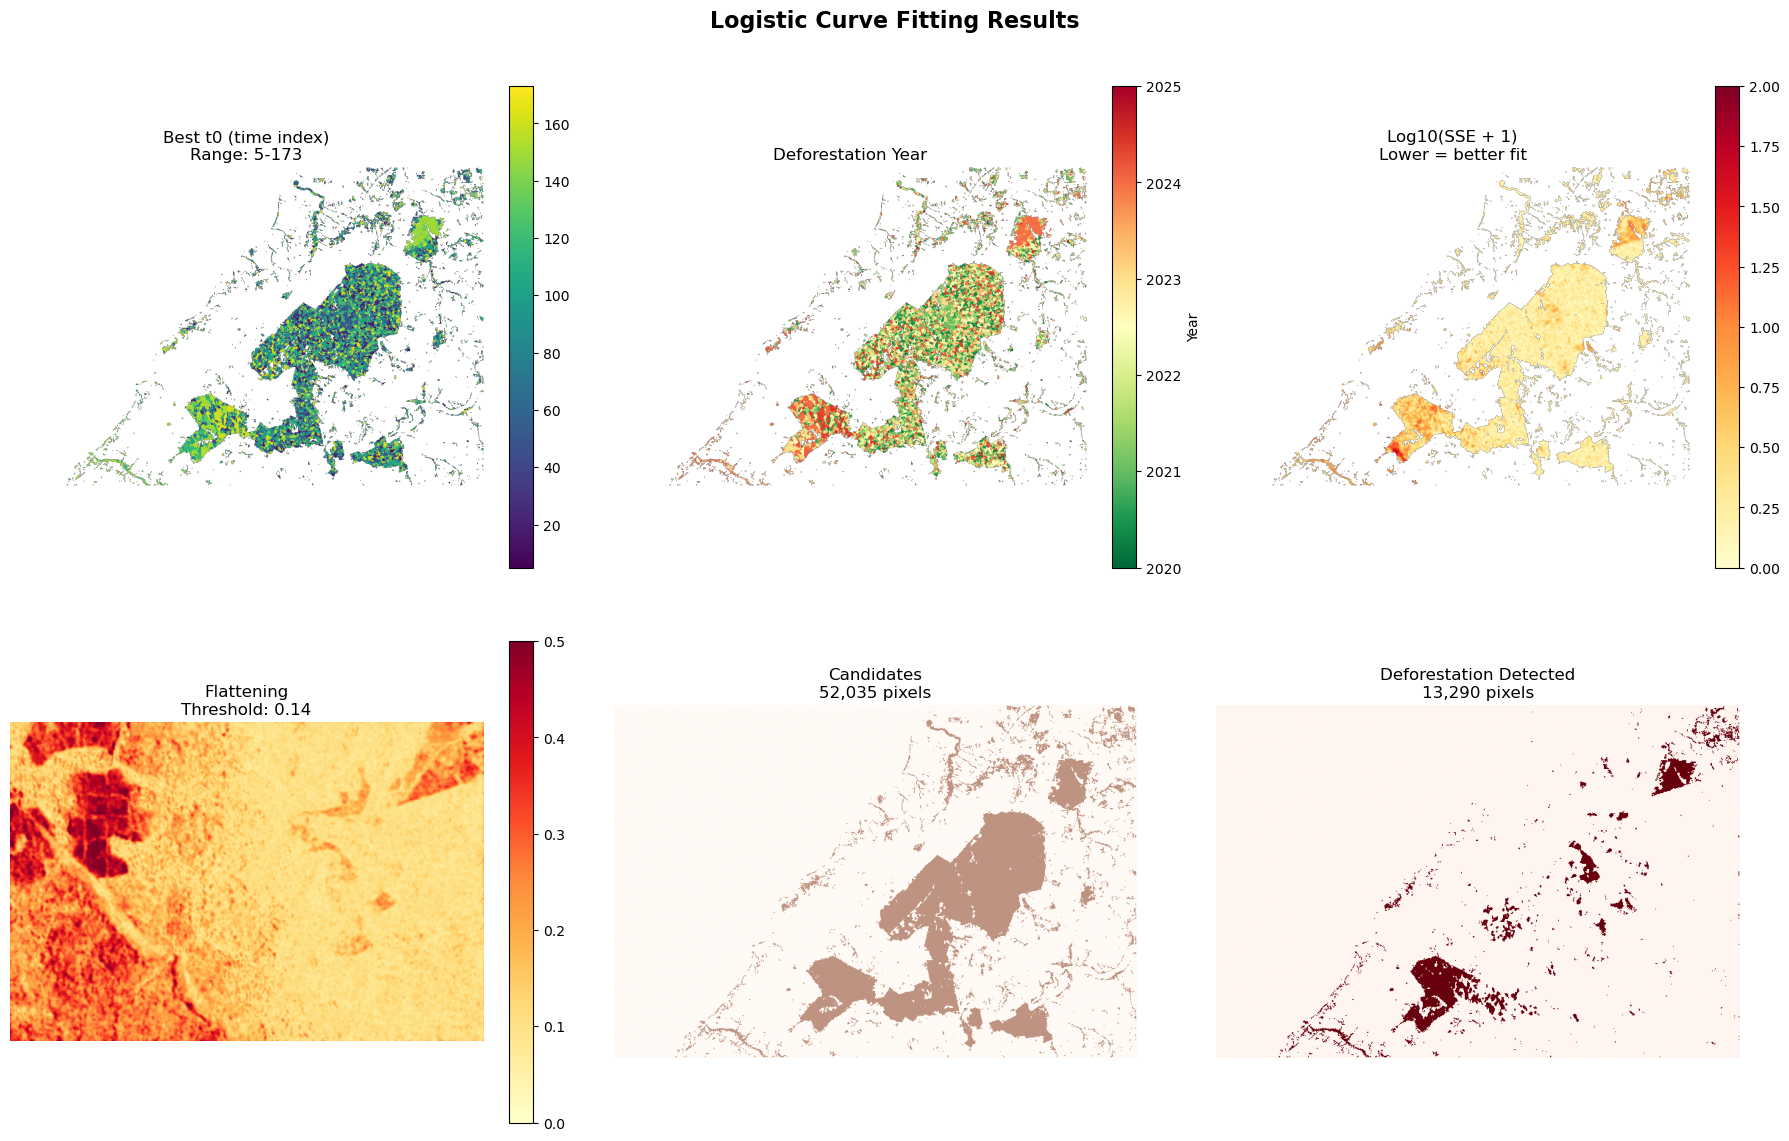


SUMMARY

Deforestation timing:
  Earliest: 2020.12
  Latest:   2024.80
  Mean:     2022.96

Detections by year:
  2020: 967 pixels
  2021: 2,222 pixels
  2022: 2,787 pixels
  2023: 3,892 pixels
  2024: 3,422 pixels


In [9]:

# ===================== VISUALIZE RESULTS =====================
print("\nVisualizing results...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Best t0
im1 = axes[0, 0].imshow(best_t0_map, cmap='viridis', vmin=idx_min, vmax=idx_max)
axes[0, 0].set_title(f'Best t0 (time index)\nRange: {idx_min}-{idx_max}')
axes[0, 0].axis('off')
plt.colorbar(im1, ax=axes[0, 0], fraction=0.046)

# Deforestation year
im2 = axes[0, 1].imshow(defor_years, cmap='RdYlGn_r', vmin=2020, vmax=2025)
axes[0, 1].set_title('Deforestation Year')
axes[0, 1].axis('off')
plt.colorbar(im2, ax=axes[0, 1], fraction=0.046, label='Year')

# SSE
im3 = axes[0, 2].imshow(np.log10(best_sse_map + 1), cmap='YlOrRd', vmin=0, vmax=2)
axes[0, 2].set_title('Log10(SSE + 1)\nLower = better fit')
axes[0, 2].axis('off')
plt.colorbar(im3, ax=axes[0, 2], fraction=0.046)

# Flattening
im4 = axes[1, 0].imshow(flattening, cmap='YlOrRd', vmin=0, vmax=0.5)
axes[1, 0].set_title(f'Flattening\nThreshold: {FLAT_THRESH}')
axes[1, 0].axis('off')
plt.colorbar(im4, ax=axes[1, 0], fraction=0.046)

# Candidates vs final
axes[1, 1].imshow(candidate_mask, cmap='Oranges', alpha=0.5)
axes[1, 1].set_title(f'Candidates\n{candidate_mask.sum():,} pixels')
axes[1, 1].axis('off')

# Final deforestation mask
axes[1, 2].imshow(defor_mask, cmap='Reds')
axes[1, 2].set_title(f'Deforestation Detected\n{n_defor:,} pixels')
axes[1, 2].axis('off')

plt.suptitle('Logistic Curve Fitting Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== STATISTICS =====================
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if n_defor > 0:
    defor_years_valid = defor_years[defor_mask]
    print(f"\nDeforestation timing:")
    print(f"  Earliest: {np.nanmin(defor_years_valid):.2f}")
    print(f"  Latest:   {np.nanmax(defor_years_valid):.2f}")
    print(f"  Mean:     {np.nanmean(defor_years_valid):.2f}")
    
    # Year distribution
    years = np.floor(defor_years_valid).astype(int)
    unique_years, counts = np.unique(years, return_counts=True)
    print(f"\nDetections by year:")
    for year, count in zip(unique_years, counts):
        print(f"  {year}: {count:,} pixels")
else:
    print("\nNo deforestation detected!")

# # ===================== SAVE RESULTS =====================
# results = {
#     'best_t0': best_t0_map,
#     'best_sse': best_sse_map,
#     'defor_dates': defor_dates,
#     'defor_years': defor_years,
#     'defor_mask': defor_mask,
#     'flattening': flattening,
#     'amp': amp,
#     'parameters': {
#         'a_steepness': A_STEEPNESS,
#         'n_window': N_WINDOW,
#         'flat_thresh': FLAT_THRESH,
#         'sse_thresh': SSE_THRESH,
#     }
# }

# output_file = "/home/georg/data/LEON_P6_forest-agri-change/s1_timeseries/deforestation_results.pkl"
# with open(output_file, 'wb') as f:
#     pickle.dump(results, f)

# print(f"\n✓ Results saved to {output_file}")
# print("\n✓ Ready for validation with Hansen!")